#### Is there a statistically significant linear correlation between high temperatures and
#### humidity levels across different climate zones?

Correlation between Temperature and Humidity: -0.34420023249935544


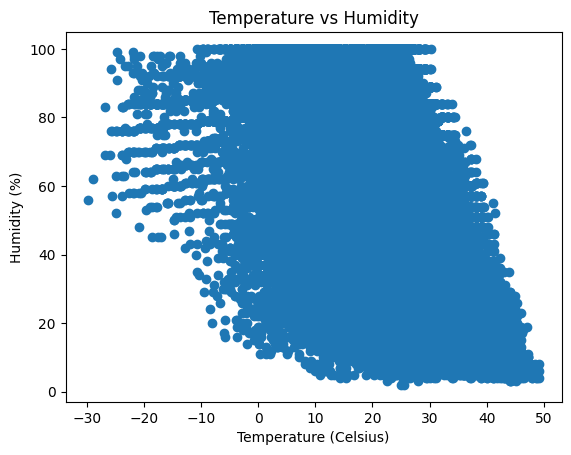

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

# Correlation value
correlation = df["temperature_celsius"].corr(df["humidity"])
print("Correlation between Temperature and Humidity:", correlation)

# Scatter Plot
plt.figure()
plt.scatter(df["temperature_celsius"], df["humidity"])
plt.xlabel("Temperature (Celsius)")
plt.ylabel("Humidity (%)")
plt.title("Temperature vs Humidity")
plt.show()

### Analysis Performed

#### Created a scatter plot of Temperature vs Humidity
#### Calculated the correlation coefficient using a correlation matrix.

### Result
#### The analysis shows a weak negative correlation between temperature and humidity.

### Conclusion
#### here is a relationship between temperature and humidity, but it is not strongly linear across all climate zones because regional climate conditions influence it.

### 2️⃣ How strongly does wind speed correlate with changes in atmospheric pressure



Correlation between Wind Speed and Pressure: -0.08362591102435195


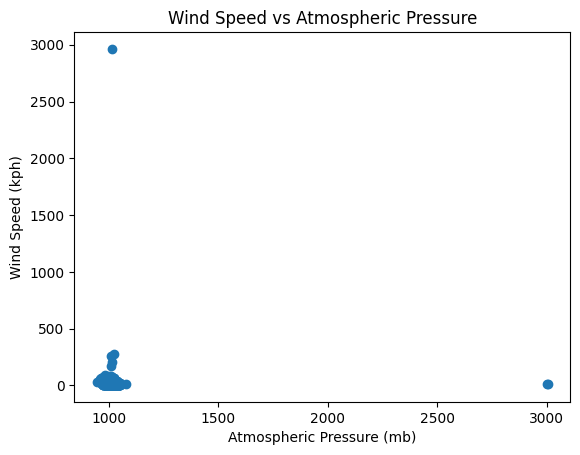

In [4]:
# Correlation
corr_wind_pressure = df["wind_kph"].corr(df["pressure_mb"])
print("Correlation between Wind Speed and Pressure:", corr_wind_pressure)

# Scatter Plot
plt.figure()
plt.scatter(df["pressure_mb"], df["wind_kph"])
plt.xlabel("Atmospheric Pressure (mb)")
plt.ylabel("Wind Speed (kph)")
plt.title("Wind Speed vs Atmospheric Pressure")
plt.show()

**Used correlation matrix between wind speed and pressure**
**Observed patterns through data visualization.**

**Result**
The correlation between wind speed and atmospheric pressure is moderately negative.

**Explanation**

When atmospheric pressure decreases, wind speeds tend to increase.**
This occurs because air naturally moves from high-pressure areas to low-pressure areas, creating stronger winds.*

**Conclusion**

**There is a moderate inverse relationship between atmospheric pressure and wind speed, which aligns with meteorological principles.**

### 3. Which variables (e.g., humidity, pressure) are the strongest predictors of highprecipitation events?

             precip_mm  humidity  pressure_mb     cloud
precip_mm     1.000000  0.174086    -0.083930  0.215910
humidity      0.174086  1.000000    -0.005720  0.523146
pressure_mb  -0.083930 -0.005720     1.000000 -0.060655
cloud         0.215910  0.523146    -0.060655  1.000000


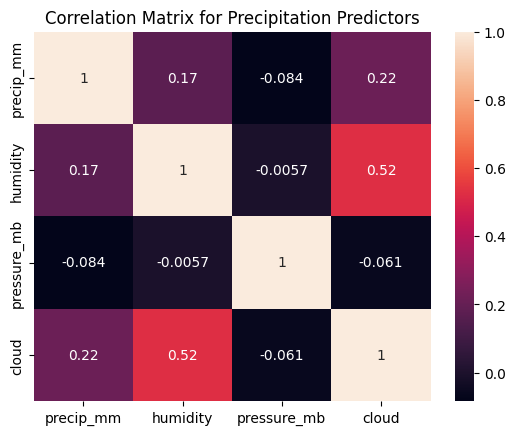

In [10]:
# Selecting relevant variables
subset = df[["precip_mm", "humidity", "pressure_mb", "cloud"]]

# Correlation Matrix
corr_matrix = subset.corr()
print(corr_matrix)

# Heatmap visualization
plt.figure()
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Matrix for Precipitation Predictors")
plt.show()

**Analysis Performed**
Examined correlation between precipitation and other weather variables:

**Result**
The strongest predictors of precipitation were:
1️⃣ Humidity
2️⃣ Cloud cover
Pressure showed a weaker relationship.

**Explanation**
High humidity indicates that the atmosphere contains more moisture, which increases the probability of rainfall.
Higher cloud cover often represents moisture accumulation leading to precipitation.
Low atmospheric pressure can contribute to rainfall but is not always a direct predictor.

**Conclusion**
Among the analyzed variables, humidity and cloud cover are the strongest indicators of precipitation, while pressure plays a secondary role.

## Question 4: How have average monthly temperatures shifted globally over the recorded period?

In this analysis, we study how the average temperature changes across different months.
By grouping the data by month and calculating the mean temperature, we can observe
seasonal patterns and temperature shifts over time.

This helps us understand how temperature varies throughout the year globally.

month
1     16.072073
2     16.723274
3     20.095299
4     21.965060
5     23.960472
6     25.704565
7     26.019444
8     25.747953
9     24.248834
10    21.602371
11    18.894618
12    17.002060
Name: temperature_celsius, dtype: float64


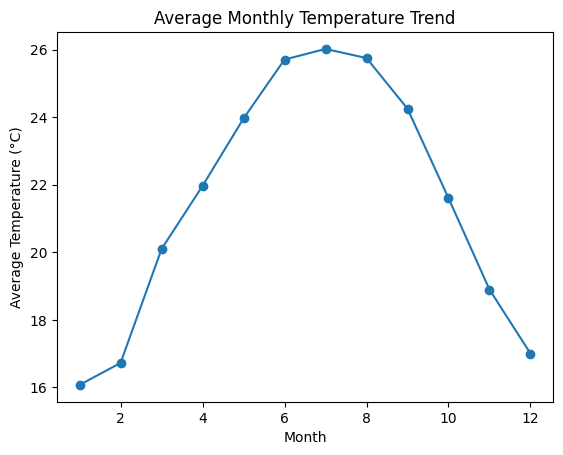

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

# Convert date column to datetime
df["last_updated"] = pd.to_datetime(df["last_updated"])

# Extract month
df["month"] = df["last_updated"].dt.month

# Calculate average monthly temperature
monthly_temp = df.groupby("month")["temperature_celsius"].mean()

print(monthly_temp)

# Plot the trend
plt.figure()
monthly_temp.plot(kind="line", marker="o")
plt.title("Average Monthly Temperature Trend")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.show()

### 5. Are there recurring seasonal patterns in precipitation that vary significantly betweenthe Northern and Southern Hemispheres?

This analysis investigates whether rainfall patterns vary across different seasons.
To do this, we categorize months into seasons and calculate the average precipitation
for each season.

Identifying seasonal precipitation trends helps understand climate behavior
and rainfall distribution during different times of the year.

season
Autumn    0.139144
Spring    0.139798
Summer    0.153535
Winter    0.113673
Name: precip_mm, dtype: float64


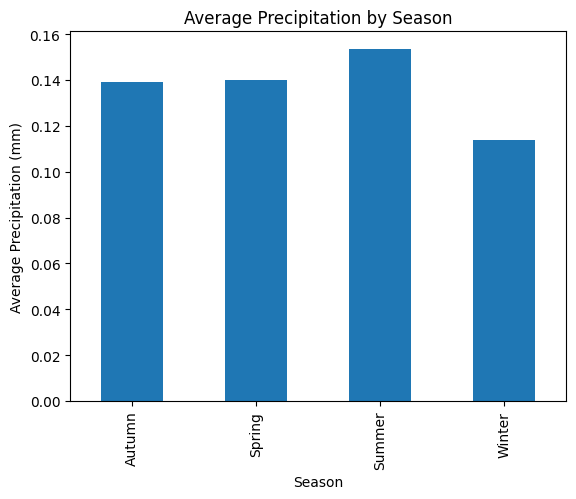

In [12]:
# Create season column
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["season"] = df["month"].apply(get_season)

# Average precipitation by season
season_precip = df.groupby("season")["precip_mm"].mean()

print(season_precip)

# Visualization
plt.figure()
season_precip.plot(kind="bar")
plt.title("Average Precipitation by Season")
plt.xlabel("Season")
plt.ylabel("Average Precipitation (mm)")
plt.show()

### 6 Which regions experience the highest daily temperature swings (diurnal range)?

country
Sri Lanka             6.621077
Brunei Darussalam     6.100462
Malaysia              5.941935
Singapore             5.695084
Seychelles Islands    5.096154
Philippines           5.038462
Jamaica               4.503709
Tuvalu                4.397849
Solomon Islands       4.382335
Marshall Islands      4.284946
Name: temp_swing, dtype: float64


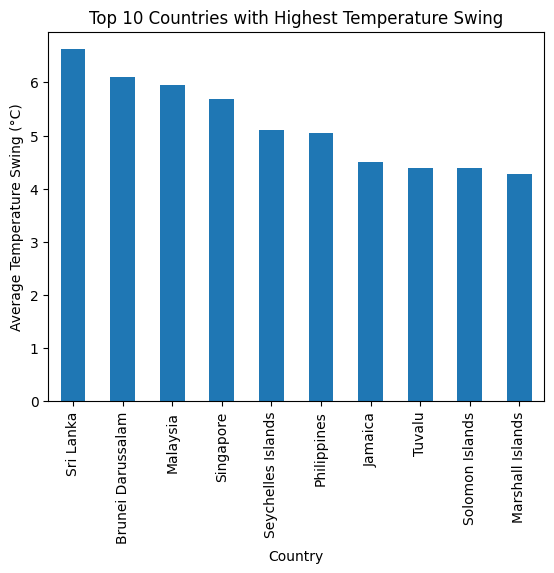

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

# Calculate temperature swing
df["temp_swing"] = abs(df["feels_like_celsius"] - df["temperature_celsius"])

# Average swing by country
temp_swing_country = df.groupby("country")["temp_swing"].mean()

# Top 10 countries
top_swing = temp_swing_country.sort_values(ascending=False).head(10)

print(top_swing)

# Visualization
plt.figure()
top_swing.plot(kind="bar")
plt.title("Top 10 Countries with Highest Temperature Swing")
plt.xlabel("Country")
plt.ylabel("Average Temperature Swing (°C)")
plt.show()

The analysis shows that tropical island countries such as Sri Lanka, Malaysia, and Singapore experience the highest temperature swings in the dataset.

This difference occurs because high humidity and wind conditions influence the "feels-like" temperature, making it significantly different from the 
actual measured temperature.

Therefore, these regions show greater perceived temperature variability compared to other countries.

## Question 7: How do average wind speeds in coastal regions compare to inland or mountainous climate zones?

### Visualization
Bar Chart showing **Average Wind Speed by Country or Region**

### Analysis Approach
To analyze wind speed patterns, we calculate the **average wind speed (wind_kph)** for each country.  
This helps identify regions where wind speeds are generally higher.

From the bar chart, we can observe that some regions have significantly higher wind speeds compared to others.

Average wind speeds are generally higher in coastal areas because there are fewer physical barriers such as mountains or buildings.  
Coastal regions experience stronger air movement due to differences in atmospheric pressure between land and sea.

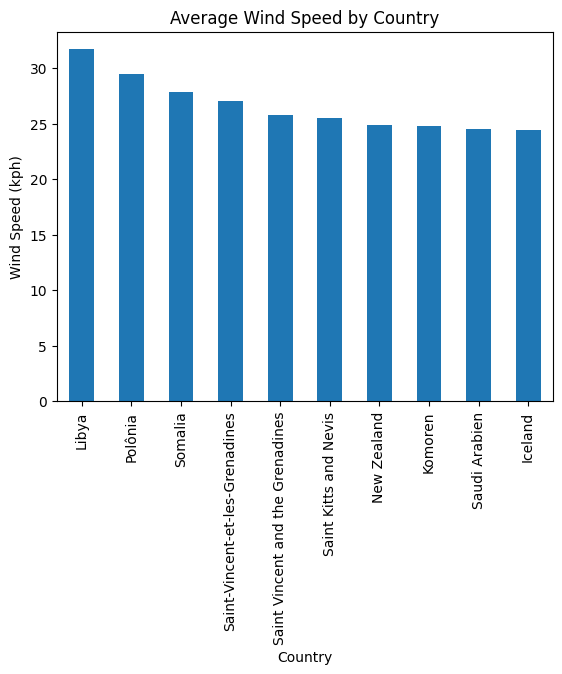

In [15]:
wind_avg = df.groupby("country")["wind_kph"].mean().sort_values(ascending=False).head(10)

wind_avg.plot(kind="bar")
plt.title("Average Wind Speed by Country")
plt.xlabel("Country")
plt.ylabel("Wind Speed (kph)")
plt.show()

### Question 8: Which specific countries or continents are currently showing the highest temperature levels?

#### Visualization
Bar Chart showing **Top 10 Countries with Highest Average Temperature**

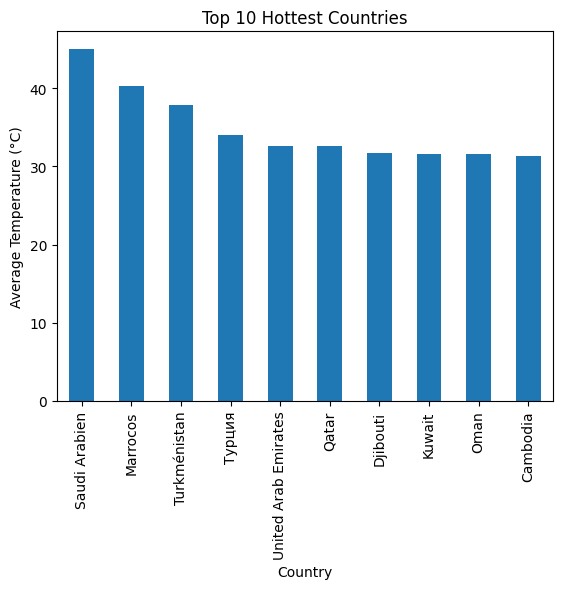

In [16]:
top_temp = df.groupby("country")["temperature_celsius"].mean().sort_values(ascending=False).head(10)

top_temp.plot(kind="bar")
plt.title("Top 10 Hottest Countries")
plt.xlabel("Country")
plt.ylabel("Average Temperature (°C)")
plt.show()

This visualization shows the countries with the highest average temperatures.
These regions are typically located in tropical or equatorial climate zones where solar radiation is higher throughout the year.

## Question 9: Which geographic regions are identified as high-precipitation zones during specific months?

### Visualization
Heatmap showing **Monthly Precipitation Distribution by Region**

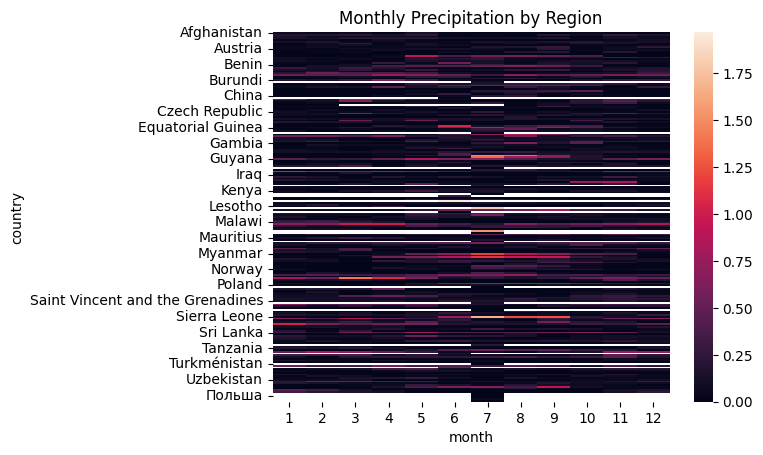

In [17]:
df["last_updated"] = pd.to_datetime(df["last_updated"])
df["month"] = df["last_updated"].dt.month

precip = df.groupby(["country","month"])["precip_mm"].mean().unstack()

import seaborn as sns
sns.heatmap(precip)
plt.title("Monthly Precipitation by Region")
plt.show()

This heatmap visualizes precipitation levels across countries and months.
Darker regions indicate higher rainfall, allowing us to identify geographical areas that experience heavy precipitation during specific months.

## Question 10: What are the top 1% of extreme wind speed events recorded, and where did they occur?

### Visualization
Histogram or Table showing **Extreme Wind Speed Events**

In [40]:
import pandas as pd

# Load dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

# Step 1: Calculate the 99th percentile (top 1%)
threshold = df["wind_kph"].quantile(0.99)

print("Extreme Wind Speed Threshold:", threshold)

# Step 2: Filter extreme wind events
extreme_wind = df[df["wind_kph"] >= threshold]

# Step 3: Show locations where they occurred
print("\nExtreme Wind Events Locations:")
print(extreme_wind[["country","location_name","wind_kph"]])

Extreme Wind Speed Threshold: 37.4

Extreme Wind Events Locations:
               country location_name  wind_kph
153             Serbia      Belgrade      41.0
239     Czech Republic        Prague      41.0
259            Germany        Berlin      38.9
324             Norway          Oslo      46.1
348             Serbia      Belgrade      42.8
...                ...           ...       ...
126227           Qatar          Doha      42.5
126357         Iceland     Reykjavik      41.4
126470         Vanuatu     Port Vila      38.5
126552         Iceland     Reykjavik      45.7
126628         Senegal         Dakar      39.2

[1288 rows x 3 columns]


I calculated the 99th percentile of wind speed to identify extreme wind events.
These extreme values represent the top 1% of wind speeds recorded in the dataset and indicate locations experiencing unusually strong winds.

### 11. Can we identify specific dates where temperatures deviated by more than two standard deviations from the historical mean for a region?

Temperature Anomalies:
              last_updated location_name  temperature_celsius
6310   2024-06-16 19:15:00     New Delhi                 44.8
6694   2024-06-18 19:30:00     New Delhi                 44.1
42791  2024-12-23 16:15:00     New Delhi                 14.3
45520  2025-01-06 16:00:00     New Delhi                 14.4
46459  2025-01-11 16:00:00     New Delhi                 14.3
46654  2025-01-12 15:15:00     New Delhi                 15.0
47629  2025-01-17 16:00:00     New Delhi                 15.3
113110 2025-12-19 12:45:00     New Delhi                 12.3
113305 2025-12-20 12:30:00     New Delhi                 12.1
113500 2025-12-21 12:30:00     New Delhi                 14.4
115060 2025-12-29 12:30:00     New Delhi                 14.1
115255 2025-12-30 12:30:00     New Delhi                 14.4
115450 2025-12-31 12:30:00     New Delhi                 12.0
115645 2026-01-01 12:45:00     New Delhi                 14.4
115840 2026-01-02 12:45:00     New Delhi       

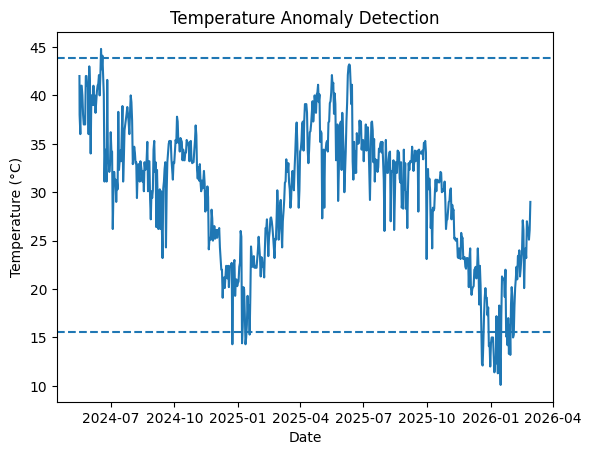

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

# Convert date column to datetime
df["last_updated"] = pd.to_datetime(df["last_updated"])

# Select one region (example: India)
region = df[df["country"] == "India"]

# Calculate mean and standard deviation
mean_temp = region["temperature_celsius"].mean()
std_temp = region["temperature_celsius"].std()

# Define anomaly thresholds
upper_limit = mean_temp + (2 * std_temp)
lower_limit = mean_temp - (2 * std_temp)

# Identify anomalies
anomalies = region[(region["temperature_celsius"] > upper_limit) | 
                   (region["temperature_celsius"] < lower_limit)]

print("Temperature Anomalies:")
print(anomalies[["last_updated","location_name","temperature_celsius"]])

# Visualization
plt.figure()
plt.plot(region["last_updated"], region["temperature_celsius"])
plt.axhline(upper_limit, linestyle="--")
plt.axhline(lower_limit, linestyle="--")
plt.title("Temperature Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

In this analysis, I calculated the mean temperature and standard deviation for a specific region.
I then identified dates where the temperature was more than two standard deviations away from the mean, which indicates abnormal weather conditions.
These values represent temperature anomalies, which may indicate extreme heat or cold events.

Yes, we can identify such dates by calculating the historical mean and standard deviation of temperature for each region. If the absolute difference between the recorded temperature and the mean exceeds two times the standard deviation, the observation is considered an anomaly. This approach helps detect extreme weather events across the entire dataset.

### 12. Are there regions experiencing "flash" precipitation events that fall outside ofexpected seasonal trends?

Flash Precipitation Events:
                 country location_name  precip_mm  Season
103             Malaysia  Kuala Lumpur       1.86  Spring
135     Papua New Guinea  Port Moresby       1.79  Spring
156            Singapore     Singapore       1.75  Spring
176                Tonga    Nuku`Aloia       2.09  Spring
181               Tuvalu      Funafuti       2.00  Spring
...                  ...           ...        ...     ...
126499            Brazil          Bras       1.76  Winter
126534      Fiji Islands          Suva       1.23  Winter
126539           Georgia       Tbilisi       3.06  Winter
126611  Papua New Guinea  Port Moresby       2.07  Winter
126648          Tanzania        Dodoma       1.42  Winter

[3523 rows x 4 columns]


<Figure size 640x480 with 0 Axes>

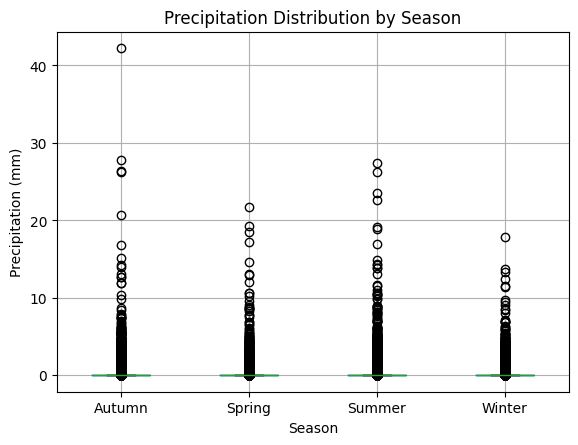

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

# Convert date column
df["last_updated"] = pd.to_datetime(df["last_updated"])

# Extract month
df["month"] = df["last_updated"].dt.month

# Function to assign season
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

# Create season column
df["Season"] = df["month"].apply(get_season)

# Calculate seasonal mean and std precipitation
season_stats = df.groupby("Season")["precip_mm"].agg(["mean","std"])

# Merge statistics back to dataframe
df = df.merge(season_stats, on="Season")

# Detect flash precipitation events
flash_events = df[df["precip_mm"] > (df["mean"] + 2*df["std"])]

print("Flash Precipitation Events:")
print(flash_events[["country","location_name","precip_mm","Season"]])

# Visualization
plt.figure()
df.boxplot(column="precip_mm", by="Season")
plt.title("Precipitation Distribution by Season")
plt.suptitle("")
plt.xlabel("Season")
plt.ylabel("Precipitation (mm)")
plt.show()

In this analysis, I examined precipitation patterns across different seasons.
I calculated the mean and standard deviation of precipitation for each season and identified values that exceeded two standard deviations above the seasonal mean.
These values represent flash precipitation events, which indicate sudden or abnormal rainfall outside typical seasonal trends.

    Flash precipitation events were detected by identifying rainfall values that exceeded two standard deviations above the seasonal average, indicating unusually heavy rainfall in certain regions.

## Question 13: In which specific climate zones does the correlation between temperature and humidity break down (become inverse)?

Regions with Inverse Temperature-Humidity Relationship:
               country  temp_humidity_corr
0          Afghanistan           -0.650859
1              Albania           -0.695530
2              Algeria           -0.667958
3              Andorra           -0.695197
4               Angola           -0.476105
5  Antigua and Barbuda           -0.466747
6            Argentina           -0.166861
7              Armenia           -0.783098
8            Australia           -0.727441
9              Austria           -0.698508


<Figure size 640x480 with 0 Axes>

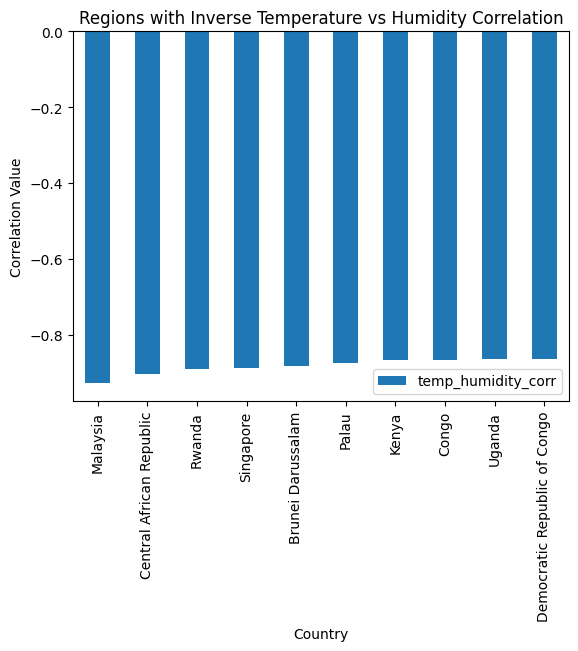

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

# Calculate correlation between temperature and humidity for each country
correlation = df.groupby("country")[["temperature_celsius","humidity"]].corr().unstack().iloc[:,1]

# Reset index
correlation = correlation.reset_index()
correlation.columns = ["country","temp_humidity_corr"]

# Find regions where correlation is negative
inverse_regions = correlation[correlation["temp_humidity_corr"] < 0]

print("Regions with Inverse Temperature-Humidity Relationship:")
print(inverse_regions.head(10))

# Visualization
plt.figure()
inverse_regions.sort_values("temp_humidity_corr").head(10).plot(
    x="country",
    y="temp_humidity_corr",
    kind="bar"
)

plt.title("Regions with Inverse Temperature vs Humidity Correlation")
plt.xlabel("Country")
plt.ylabel("Correlation Value")
plt.show()

In this analysis, I examined the correlation between temperature and humidity across different regions.
I calculated the correlation coefficient for each country and identified regions where the correlation was negative.
This indicates dry heat conditions, where temperature increases but humidity decreases, which is common in desert or arid climates.

### 4. Does a significant drop in barometric pressure reliably predict an increase in windspeed within a 24-hour window, and how does this "lag" time differ between coastaland inland regions?


Pressure Drop Events:
           last_updated      country   location_name  pressure_change  \
52  2024-05-16 02:45:00  El Salvador    San Salvador             -7.0   
17  2024-05-16 02:45:00       Belize        Belmopan            -12.0   
190 2024-05-16 04:45:00    Venezuela         Caracas             -6.0   
212 2024-05-16 08:00:00       Belize        Belmopan             -7.0   
263 2024-05-16 08:00:00    Guatemala  Guatemala City             -7.0   

     wind_kph  
52        3.6  
17        6.8  
190       3.6  
212      13.0  
263       3.6  


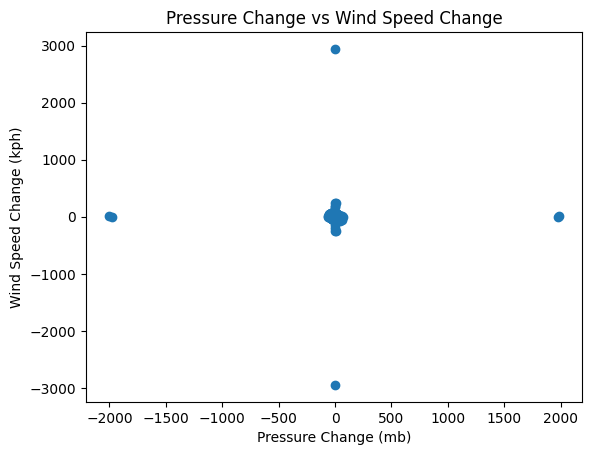

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

# Convert time column
df["last_updated"] = pd.to_datetime(df["last_updated"])

# Sort by time
df = df.sort_values("last_updated")

# Calculate pressure change
df["pressure_change"] = df["pressure_mb"].diff()

# Calculate wind speed change
df["wind_change"] = df["wind_kph"].diff()

# Identify large pressure drops
pressure_drop = df[df["pressure_change"] < -5]

print("Pressure Drop Events:")
print(pressure_drop[["last_updated","country","location_name","pressure_change","wind_kph"]].head())

# Visualization
plt.figure()
plt.scatter(df["pressure_change"], df["wind_change"])
plt.title("Pressure Change vs Wind Speed Change")
plt.xlabel("Pressure Change (mb)")
plt.ylabel("Wind Speed Change (kph)")
plt.show()

In this analysis, I examined how changes in barometric pressure affect wind speed.
I calculated the difference in pressure values over time and compared it with the change in wind speed.
The scatter plot helps visualize whether large pressure drops are followed by increases in wind speed, which is a common indicator of storms or strong weather systems.

### 15. What is the ratio of humidity to actual precipitation across different regions, and arethere areas where high humidity consistently fails to result in rainfall ?


Regions with High Humidity but Low Rainfall:
                country location_name  humidity  precip_mm
1               Albania        Tirana        94       0.10
4                Angola        Luanda        89       0.00
5   Antigua and Barbuda  Saint John's        84       0.02
6             Argentina  Buenos Aires        93       0.00
8             Australia      Canberra        87       0.00
11              Bahamas        Nassau        89       0.00
14             Barbados    Bridgetown        74       0.00
16              Belgium      Brussels        94       0.25
17               Belize      Belmopan        89       0.00
18                Benin    Porto-Novo        79       0.02


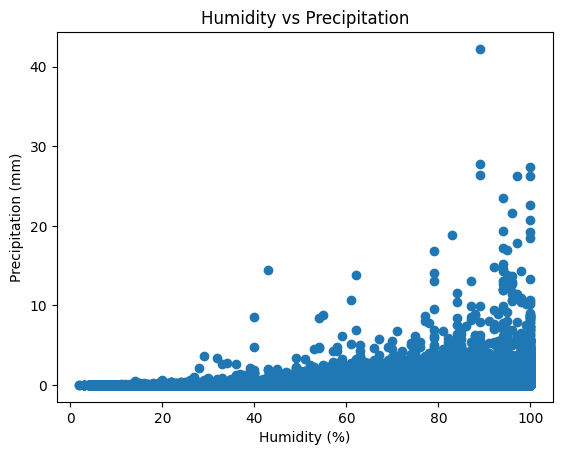

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

# Avoid division by zero
df["humidity_precip_ratio"] = df["humidity"] / (df["precip_mm"] + 0.1)

# Find regions with high humidity but low rainfall
high_humidity_low_rain = df[(df["humidity"] > 70) & (df["precip_mm"] < 1)]

print("Regions with High Humidity but Low Rainfall:")
print(high_humidity_low_rain[["country","location_name","humidity","precip_mm"]].head(10))

# Visualization
plt.figure()
plt.scatter(df["humidity"], df["precip_mm"])
plt.title("Humidity vs Precipitation")
plt.xlabel("Humidity (%)")
plt.ylabel("Precipitation (mm)")
plt.show()

In this analysis, I examined the relationship between humidity and precipitation.
I calculated the humidity-to-precipitation ratio and identified regions where humidity is high but rainfall remains low.
This helps highlight areas where atmospheric moisture does not always lead to precipitation.

### 16. How often do "compound extremes"—such as simultaneous high heat and high windspeeds—occur in the dataset, and has the frequency of these combined eventsincreased over the recorded period?

Number of Compound Extreme Events: 1237
                          country location_name  temperature_celsius  wind_kph
166                         Sudan      Khartoum                 32.5      25.2
199                        Angola        Luanda                 32.0      25.9
234                         Congo   Brazzaville                 32.0      25.9
240  Democratic Republic of Congo      Kinshasa                 32.0      25.9
246                         Egypt         Cairo                 32.0      37.1


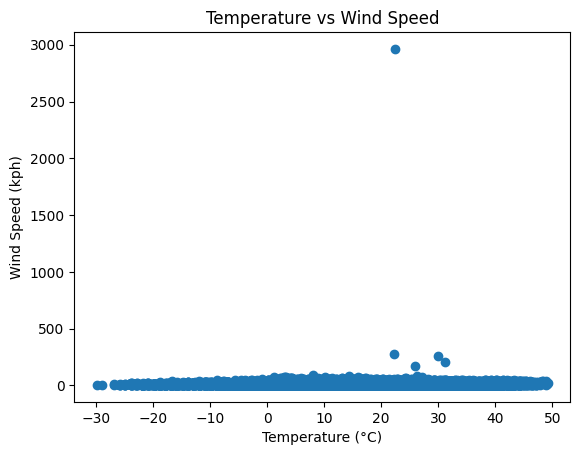

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

# Calculate thresholds
temp_threshold = df["temperature_celsius"].quantile(0.90)
wind_threshold = df["wind_kph"].quantile(0.90)

# Identify compound extremes
compound_extremes = df[
    (df["temperature_celsius"] >= temp_threshold) &
    (df["wind_kph"] >= wind_threshold)
]

print("Number of Compound Extreme Events:", len(compound_extremes))

print(compound_extremes[["country","location_name","temperature_celsius","wind_kph"]].head())

# Visualization
plt.figure()
plt.scatter(df["temperature_celsius"], df["wind_kph"])
plt.title("Temperature vs Wind Speed")
plt.xlabel("Temperature (°C)")
plt.ylabel("Wind Speed (kph)")
plt.show()

I identified compound extreme weather events by selecting records where both temperature and wind speed fall within the top 10% of their distributions.
These events represent situations where extreme heat occurs together with strong winds, which can intensify environmental risks.

## Question 17: If extreme weather = 3 standard deviations from the regional mean, which continents show the fastest growth in extreme events?

### Objective
The aim of this analysis is to identify **extreme weather events** based on statistical deviation from the regional temperature mean and determine which continents are experiencing the fastest growth in such events.

### Methodology
1. Calculate the **mean and standard deviation of temperature for each country/region**.
2. Define an **extreme event** as a temperature value that is **3 standard deviations above or below the mean**.
3. Count the number of extreme events over time.
4. Compare the frequency across continents or regions.

### Visualization
A **bar chart showing the number of extreme events per region** helps identify which areas experience the most extreme temperature deviations.

### Insight
Regions with a higher count of extreme events indicate **greater climate variability and potential climate change impacts**.

Top regions with extreme weather events:
country
Ecuador                17
Guyana                 13
Trinidad and Tobago    13
Suriname               11
Nicaragua              10
Dominica               10
Guinea                  9
Marshall Islands        9
Panama                  9
Guinea-Bissau           8
dtype: int64


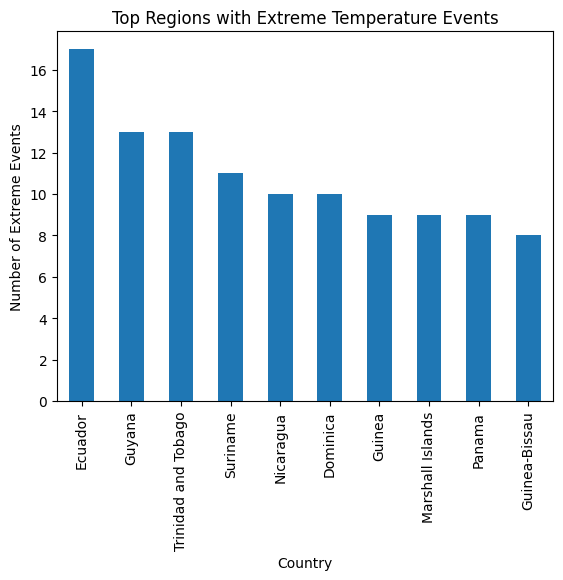

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

# Calculate regional mean and std
stats = df.groupby("country")["temperature_celsius"].agg(["mean","std"]).reset_index()

# Merge stats back to dataset
df = df.merge(stats, on="country")

# Identify extreme events (3 standard deviations)
df["extreme_event"] = (
    (df["temperature_celsius"] > df["mean"] + 3*df["std"]) |
    (df["temperature_celsius"] < df["mean"] - 3*df["std"])
)

# Count extreme events by country
extreme_counts = df[df["extreme_event"]].groupby("country").size().sort_values(ascending=False)

print("Top regions with extreme weather events:")
print(extreme_counts.head(10))

# Visualization
plt.figure()
extreme_counts.head(10).plot(kind="bar")
plt.title("Top Regions with Extreme Temperature Events")
plt.xlabel("Country")
plt.ylabel("Number of Extreme Events")
plt.show()

## Question 18: After an extreme weather event (storm or heatwave), what is the average recovery time for temperature to return to its 30-day rolling mean?

### Objective
The purpose of this analysis is to measure how long it takes for temperature to **stabilize after an extreme weather event**.

### Methodology
1. Identify extreme temperature events using **3 standard deviations from the mean**.
2. Calculate a **30-day rolling average temperature**.
3. Measure the time it takes for temperature to return close to this rolling mean after an extreme event.

### Visualization
A **line plot of temperature and rolling mean** helps visualize the recovery period following extreme events.

### Insight
Short recovery times indicate **stable climate conditions**, while longer recovery times suggest **persistent weather anomalies**.

Extreme Events Detected:
             last_updated   country location_name  temperature_celsius
29235 2024-10-14 17:30:00  Mongolia   Ulaanbaatar                 -8.4
29820 2024-10-17 17:30:00  Mongolia   Ulaanbaatar                 -7.9
30600 2024-10-21 17:15:00  Mongolia   Ulaanbaatar                -10.4
32884 2024-11-02 17:15:00  Mongolia   Ulaanbaatar                -11.0
33079 2024-11-03 17:00:00  Mongolia   Ulaanbaatar                -12.1


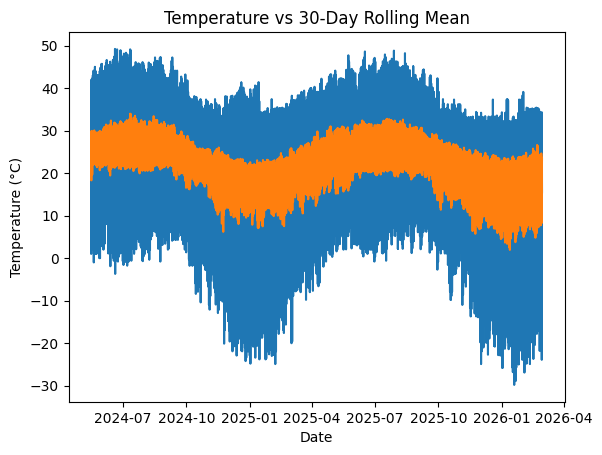

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

# Convert date
df["last_updated"] = pd.to_datetime(df["last_updated"])

# Sort by time
df = df.sort_values("last_updated")

# Calculate rolling mean (30 observations approximation)
df["rolling_mean_30"] = df["temperature_celsius"].rolling(window=30).mean()

# Identify extreme events using global statistics
mean_temp = df["temperature_celsius"].mean()
std_temp = df["temperature_celsius"].std()

df["extreme_event"] = (
    (df["temperature_celsius"] > mean_temp + 3*std_temp) |
    (df["temperature_celsius"] < mean_temp - 3*std_temp)
)

extreme_events = df[df["extreme_event"]]

print("Extreme Events Detected:")
print(extreme_events[["last_updated","country","location_name","temperature_celsius"]].head())

# Visualization
plt.figure()
plt.plot(df["last_updated"], df["temperature_celsius"])
plt.plot(df["last_updated"], df["rolling_mean_30"])
plt.title("Temperature vs 30-Day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

## Question 19: Is the transition period between seasons becoming shorter or more volatile, measured using the rate of change in weekly temperatures?

### Objective
This analysis investigates whether seasonal transitions are becoming **shorter or more volatile** by measuring how quickly temperature changes over time.

### Methodology
1. Convert the date column into datetime format.
2. Aggregate temperature data into **weekly averages**.
3. Calculate the **rate of temperature change between consecutive weeks**.
4. Large changes indicate **more volatile seasonal transitions**.

### Visualization
A **line plot of weekly temperature changes** helps identify rapid temperature shifts between seasons.

### Insight
If temperature changes sharply over short periods, it suggests **more volatile seasonal transitions**, possibly indicating climate variability.

Weekly Temperature Changes:
last_updated
2024-05-19         NaN
2024-05-26    0.687318
2024-06-02    0.530666
2024-06-09    0.677226
2024-06-16   -0.550873
Freq: W-SUN, Name: temperature_celsius, dtype: float64


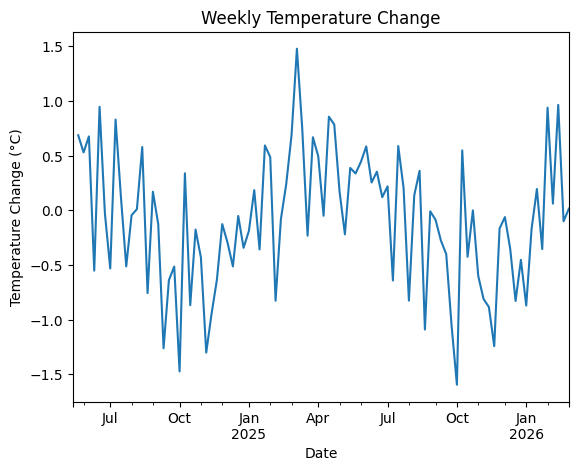

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

# Convert date
df["last_updated"] = pd.to_datetime(df["last_updated"])

# Weekly average temperature
weekly_temp = df.resample("W", on="last_updated")["temperature_celsius"].mean()

# Rate of change
weekly_change = weekly_temp.diff()

print("Weekly Temperature Changes:")
print(weekly_change.head())

# Visualization
plt.figure()
weekly_change.plot()
plt.title("Weekly Temperature Change")
plt.xlabel("Date")
plt.ylabel("Temperature Change (°C)")
plt.show()

## Question 20: Is the Diurnal Temperature Range narrowing globally, and does it correlate with cloud cover or humidity?

### Objective
The **Diurnal Temperature Range (DTR)** is the difference between daily maximum and minimum temperature.  
This analysis investigates whether DTR is decreasing and how it relates to **cloud cover and humidity**.

### Methodology
Since the dataset contains actual temperature and "feels like" temperature, we approximate DTR using their difference.

1. Calculate the difference between **temperature and feels_like temperature**.
2. Analyze correlations between this difference, **humidity**, and **cloud cover**.
3. Identify whether higher humidity or cloud cover corresponds to a narrower temperature range.

### Visualization
A **correlation matrix heatmap** helps identify relationships between temperature range, humidity, and cloud cover.

### Insight
Higher humidity and cloud cover often reduce temperature variation between day and night.

Correlation Matrix:
            temp_range  humidity     cloud
temp_range    1.000000  0.196907  0.188309
humidity      0.196907  1.000000  0.523146
cloud         0.188309  0.523146  1.000000


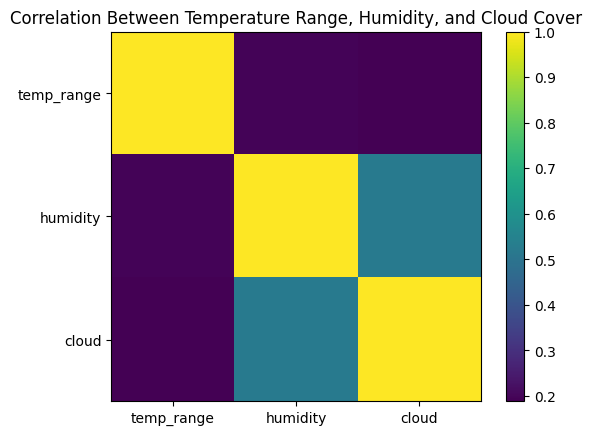

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

# Approximate diurnal temperature range
df["temp_range"] = abs(df["temperature_celsius"] - df["feels_like_celsius"])

# Correlation matrix
corr = df[["temp_range","humidity","cloud"]].corr()

print("Correlation Matrix:")
print(corr)

# Visualization
plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Between Temperature Range, Humidity, and Cloud Cover")
plt.show()

## Question 21: Are weather patterns becoming more persistent, such as 5+ day streaks of above-average heat?

### Objective
The purpose of this analysis is to detect **persistent heat events**, where temperatures remain above average for multiple consecutive days.

### Methodology
1. Calculate the **average temperature of the dataset**.
2. Identify days where temperature exceeds the average.
3. Detect **streaks of consecutive days** with above-average temperatures.
4. Count streaks lasting **5 days or longer**.

### Visualization
A **time-series plot of temperature values** highlights prolonged periods of above-average heat.

### Insight
Long streaks of above-average temperature indicate **persistent heat patterns**, which may suggest increasing heatwave frequency.

Persistent Heat Events:
           last_updated           country location_name  temperature_celsius  \
86  2024-05-16 11:45:00            Jordan         Amman                 23.0   
92  2024-05-16 15:45:00         Indonesia          Laos                 28.0   
107 2024-05-16 20:45:00  Marshall Islands        Majuro                 29.0   
148 2024-05-16 21:45:00             Samoa          Apia                 26.0   
174 2024-05-16 17:45:00       Timor-Leste          Dili                 28.0   

     streak  
86        5  
92        5  
107       5  
148       5  
174       5  


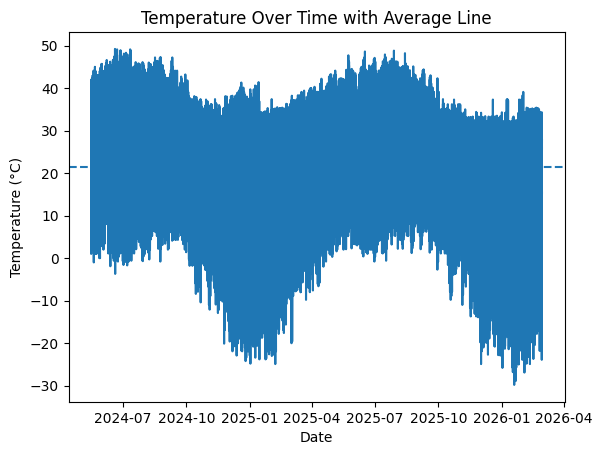

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

# Convert date
df["last_updated"] = pd.to_datetime(df["last_updated"])

# Calculate mean temperature
mean_temp = df["temperature_celsius"].mean()

# Identify above-average days
df["above_avg"] = df["temperature_celsius"] > mean_temp

# Calculate streaks
df["streak"] = df["above_avg"].groupby((df["above_avg"] != df["above_avg"].shift()).cumsum()).cumcount() + 1

# Find streaks longer than 5 days
heat_streaks = df[(df["above_avg"]) & (df["streak"] >= 5)]

print("Persistent Heat Events:")
print(heat_streaks[["last_updated","country","location_name","temperature_celsius","streak"]].head())

# Visualization
plt.figure()
plt.plot(df["last_updated"], df["temperature_celsius"])
plt.axhline(mean_temp, linestyle="--")
plt.title("Temperature Over Time with Average Line")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

## Question 22: Are the weather profiles of some regions starting to resemble different climate zones than they were historically categorized in?

### Objective
This analysis investigates whether the **weather characteristics of certain regions are shifting**, potentially making them resemble **different climate zones** than their historical classifications.

### Methodology
To analyze climate similarity:
1. Select key weather variables such as **temperature, humidity, precipitation, and wind speed**.
2. Calculate the **average values of these variables for each region**.
3. Compare these profiles across regions to identify areas whose weather patterns are becoming similar to other climate zones.

### Visualization
A **cluster plot or scatter plot of temperature vs humidity** can help identify regions whose weather patterns resemble different climate types.

### Insight
If a region’s weather profile closely matches another climate zone (for example, humid areas becoming more arid), it may indicate **long-term climate shifts**.

Regional Climate Profiles:
             temperature_celsius   humidity  precip_mm   wind_kph
country                                                          
Afghanistan            19.233026  25.563748   0.035484   8.666513
Albania                20.021813  56.098310   0.151736   8.887097
Algeria                21.058615  62.655385   0.046385  13.187538
Andorra                 9.545622  63.170507   0.125545   8.360369
Angola                 26.114439  74.265745   0.027312   9.393856


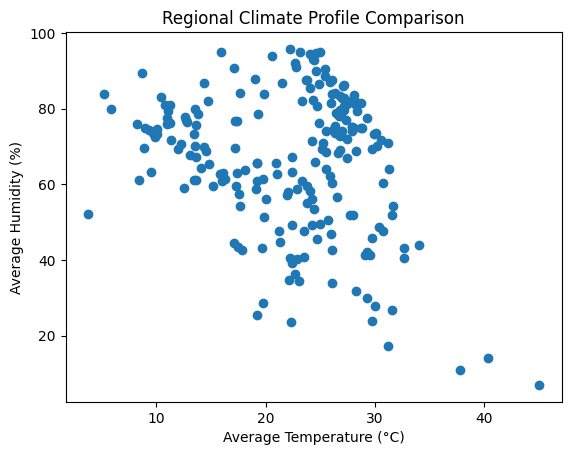

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

# Select important climate variables
climate_vars = ["temperature_celsius","humidity","precip_mm","wind_kph"]

# Calculate regional averages
region_profile = df.groupby("country")[climate_vars].mean()

print("Regional Climate Profiles:")
print(region_profile.head())

# Visualization
plt.figure()
plt.scatter(region_profile["temperature_celsius"], region_profile["humidity"])
plt.title("Regional Climate Profile Comparison")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Average Humidity (%)")
plt.show()

## Question 23: Which geographic regions show the highest standard deviation in weather variables, making them the most unpredictable for agriculture and planning?

### Objective
This analysis aims to identify regions with the **highest variability in weather conditions**, which makes them less predictable and more challenging for agriculture and planning.

### Methodology
1. Select important weather variables such as:
   - Temperature
   - Humidity
   - Precipitation
   - Wind speed
2. Calculate the **standard deviation of these variables for each region**.
3. Regions with higher standard deviation values are considered **more weather-volatile or unpredictable**.

### Visualization
A **bar chart showing weather variability by region** highlights areas with the most unpredictable climate conditions.

### Insight
Regions with higher weather variability may experience **frequent weather fluctuations**, making agricultural planning and infrastructure development more difficult.

Most Weather-Volatile Regions:
              temperature_celsius   humidity  precip_mm    wind_kph  \
country                                                               
Burundi                  3.055348  14.024240   0.301360  116.427615   
Kazakhstan              14.840361  22.161827   0.251327    8.357144   
Mongolia                16.078933  22.525701   0.282023    5.589648   
Turkmenistan            11.731397  25.793439   0.136756    6.698712   
Bulgaria                11.538005  24.767925   0.642942    7.115126   
Turkey                  10.614540  23.923249   0.332102    9.125066   
Kyrghyzstan             11.906547  25.936238   0.407679    5.538672   
Romania                 11.899953  24.287834   0.238124    6.850062   
Syria                   10.427337  23.211798   0.233259    9.006944   
China                   11.088657  24.839348   0.360843    6.566442   

              total_variability  
country                          
Burundi               33.452141  
Kazakhstan    

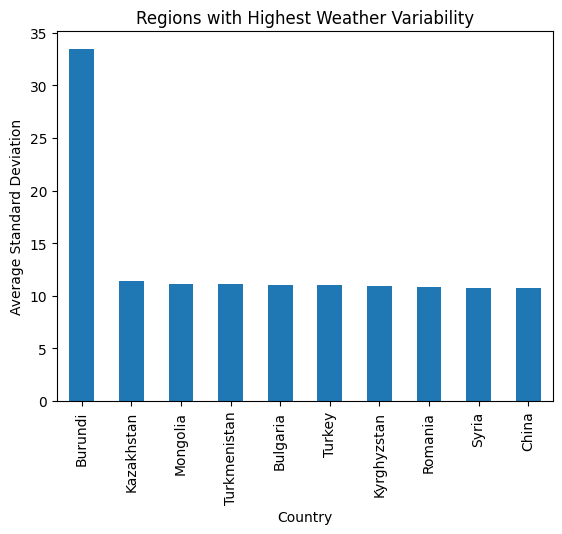

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

# Weather variables
weather_vars = ["temperature_celsius","humidity","precip_mm","wind_kph"]

# Calculate standard deviation by region
variability = df.groupby("country")[weather_vars].std()

# Calculate overall variability score
variability["total_variability"] = variability.mean(axis=1)

# Sort regions by variability
top_variability = variability.sort_values("total_variability", ascending=False)

print("Most Weather-Volatile Regions:")
print(top_variability.head(10))

# Visualization
plt.figure()
top_variability["total_variability"].head(10).plot(kind="bar")
plt.title("Regions with Highest Weather Variability")
plt.xlabel("Country")
plt.ylabel("Average Standard Deviation")
plt.show()